# El código que sigue fue generado por OpenAI GPT

La idea es comparar los resultados de clasificar dos clases no linealmente separables utilizando regresión logística y SVM en dos escenarios distintos: en uno no deformamos el espacio de features; en el segundo hacemos una transformación del espacio en otro de mayor dimensión incorporando el cuadrado de los ejes para capturar la no linealidad (si miramos las clases simuladas y las transformamos por la gráfica de un paraboloide entonces resultan linealmente separables).

In [2]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 906.6 kB/s eta 0:00:00a 0:00:01


In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [4]:
# Set seed for reproducibility
np.random.seed(42)

# Generate data for Class 1 (centered in the middle)
n1 = 100
# Modify the standard deviation value to control the degree of overlap between the classes.
class1 = pd.DataFrame({
    'x': np.random.normal(0, 0.5, n1),
    'y': np.random.normal(0, 0.5, n1),
    'label': 1
})

# Generate data for Class 0 (annular shape around Class 1)
n0 = 200
theta = np.random.uniform(0, 2 * np.pi, n0)
# again, adjust the interval as needed to generate overlapping classes.
r = np.random.uniform(1.5, 2.5, n0)
class0 = pd.DataFrame({
    'x': r * np.cos(theta),
    'y': r * np.sin(theta),
    'label': 0
})

# Combine the two classes
data = pd.concat([class1, class0], ignore_index=True)

# Add squared terms for logistic regression
data['x2'] = data['x'] ** 2
data['y2'] = data['y'] ** 2

# Separate features and labels
X = data[['x', 'y', 'x2', 'y2']]
y = data['label']

In [16]:
# Train SVM model with polynomial kernel of degree 2
svm_model = SVC(kernel='poly', degree=2, C=1, probability=True)
svm_model.fit(X[['x', 'y']], y)

# Create a grid of points to get SVM predictions for contour plotting
x_min, x_max = X['x'].min() - 1, X['x'].max() + 1
y_min, y_max = X['y'].min() - 1, X['y'].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

grid = pd.DataFrame({'x': xx.ravel(), 'y': yy.ravel()})
grid['x2'] = grid['x'] ** 2
grid['y2'] = grid['y'] ** 2

# Predict decision values on the grid for SVM
grid['decision'] = svm_model.decision_function(grid[['x', 'y']])

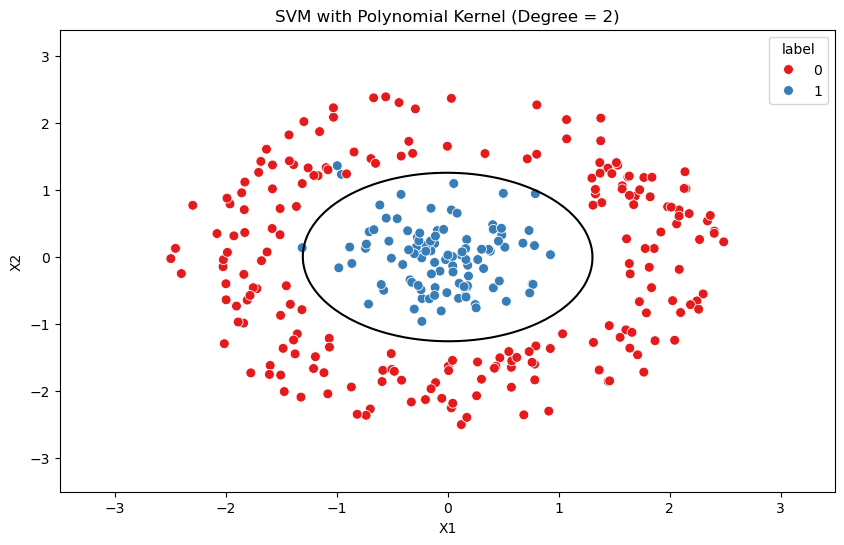

In [17]:
# Plot data and SVM decision boundary
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='x', y='y', hue='label', palette='Set1', s=50)
plt.contour(xx, yy, grid['decision'].values.reshape(xx.shape), levels=[0], colors='black')
plt.title('SVM with Polynomial Kernel (Degree = 2)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [7]:
# SVM Confusion Matrix and Error Table
data['svm_predicted'] = svm_model.predict(X[['x', 'y']])
svm_conf_matrix = confusion_matrix(y, data['svm_predicted'])
print("SVM Confusion Matrix:")
print(svm_conf_matrix)

SVM Confusion Matrix:
[[200   0]
 [  3  97]]


In [8]:
# Calculate SVM prediction error for each class
svm_error_table = pd.DataFrame(svm_conf_matrix, columns=['Predicted 0', 'Predicted 1'])
svm_error_table['Total'] = svm_error_table.sum(axis=1)
svm_error_table['Errors'] = svm_error_table['Total'] - np.diag(svm_conf_matrix)
svm_error_table['ErrorRate'] = svm_error_table['Errors'] / svm_error_table['Total']
print("SVM Error Table:")
print(svm_error_table)

SVM Error Table:
   Predicted 0  Predicted 1  Total  Errors  ErrorRate
0          200            0    200       0       0.00
1            3           97    100       3       0.03


In [9]:
# Train Logistic Regression model without squared terms
logit_model = LogisticRegression()
logit_model.fit(X[['x', 'y']], y)

# Logistic Regression Confusion Matrix and Error Table
data['logit_predicted'] = logit_model.predict(X[['x', 'y']])
logit_conf_matrix = confusion_matrix(y, data['logit_predicted'])
print("Logistic Regression Confusion Matrix:")
print(logit_conf_matrix)

Logistic Regression Confusion Matrix:
[[200   0]
 [100   0]]


In [10]:
# Calculate Logistic Regression prediction error for each class
logit_error_table = pd.DataFrame(logit_conf_matrix, columns=['Predicted 0', 'Predicted 1'])
logit_error_table['Total'] = logit_error_table.sum(axis=1)
logit_error_table['Errors'] = logit_error_table['Total'] - np.diag(logit_conf_matrix)
logit_error_table['ErrorRate'] = logit_error_table['Errors'] / logit_error_table['Total']
print("Logistic Regression Error Table:")
print(logit_error_table)

Logistic Regression Error Table:
   Predicted 0  Predicted 1  Total  Errors  ErrorRate
0          200            0    200       0        0.0
1          100            0    100     100        1.0


In [11]:
# Train Logistic Regression model with squared terms
logit_model_poly = LogisticRegression()
logit_model_poly.fit(X, y)

# Logistic Regression Confusion Matrix and Error Table (with squared terms)
data['logit_predicted_poly'] = logit_model_poly.predict(X)
logit_conf_matrix_poly = confusion_matrix(y, data['logit_predicted_poly'])
print("Logistic Regression Confusion Matrix (with squared terms):")
print(logit_conf_matrix_poly)

Logistic Regression Confusion Matrix (with squared terms):
[[200   0]
 [  2  98]]


In [12]:
# Calculate Logistic Regression prediction error for each class (with squared terms)
logit_error_table_poly = pd.DataFrame(logit_conf_matrix_poly, columns=['Predicted 0', 'Predicted 1'])
logit_error_table_poly['Total'] = logit_error_table_poly.sum(axis=1)
logit_error_table_poly['Errors'] = logit_error_table_poly['Total'] - np.diag(logit_conf_matrix_poly)
logit_error_table_poly['ErrorRate'] = logit_error_table_poly['Errors'] / logit_error_table_poly['Total']
print("Logistic Regression Error Table (with squared terms):")
print(logit_error_table_poly)

Logistic Regression Error Table (with squared terms):
   Predicted 0  Predicted 1  Total  Errors  ErrorRate
0          200            0    200       0       0.00
1            2           98    100       2       0.02
